# LANL Mustang trace
 
Mustang cluster:

- 1600 identical compute nodes
- 38400 AMD Opteron 6176 2.3GHz cores
- 102TB RAM

Trace:

- 61 months of the machine's operation
- From October 2011 to November 2016
- 2.1 million multi-node jobs submitted by 565 users

In [1]:
import json
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
NUM_NODES = 1600
NUM_CORES_PER_NODE = 24
CORE_FREQ = 2.3e9
CORE_FLOP_PER_CYCLE = 2 # double-precision FP operations per cycle (via 128-bit SSE)

IDLE_POWER_WATT = 10
EPSILON_POWER_WATT = 320 # SimGrid uses the idle value as the missing epsilon value
ALLCORES_POWER_WATT = 320

ZONE_ID = "AS0" # Zone name used in the intensity traces

In [3]:
df = pd.read_csv("datasets/mustang.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2113175 entries, 0 to 2113174
Data columns (total 9 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   user_ID          int64 
 1   group_ID         int64 
 2   submit_time      object
 3   start_time       object
 4   end_time         object
 5   wallclock_limit  object
 6   job_status       object
 7   node_count       int64 
 8   tasks_requested  int64 
dtypes: int64(4), object(5)
memory usage: 145.1+ MB


In [4]:
node_speed = NUM_CORES_PER_NODE * CORE_FREQ * CORE_FLOP_PER_CYCLE

## Utilization and queue size

Node-level view of the machine over the full trace period:

- **Utilization**: nodes allocated to running jobs, from `start_time` to `end_time`.
- **Queue size**: nodes requested by jobs waiting in queue, from `submit_time` until `start_time` (or `end_time` for jobs cancelled before starting).

Data hygiene: drop jobs with `node_count` outside `(0, 1600]`, with missing timestamps, or with negative queue/run durations.

In [5]:
for col in ["submit_time", "start_time", "end_time"]:
    df[col] = pd.to_datetime(df[col], utc=True)

valid_nodes = (df["node_count"] > 0) & (df["node_count"] <= NUM_NODES)

ran = df[valid_nodes & df["start_time"].notna() & (df["start_time"] <= df["end_time"])].copy()
ran["runtime_sec"] = (ran["end_time"] - ran["start_time"]).dt.total_seconds().clip(lower=1.0)

# Walltime estimate: the requested wallclock limit, falling back to the runtime
# when absent, and clipped so that runtime <= walltime always holds
# (TIMEOUT jobs overran their limit by a grace period in the real system).
wallclock_sec = pd.to_timedelta(ran["wallclock_limit"], errors="coerce").dt.total_seconds()
ran["walltime_sec"] = np.ceil(
    wallclock_sec.where(wallclock_sec > 0, ran["runtime_sec"]).clip(lower=ran["runtime_sec"])
)

queued = df[valid_nodes & df["submit_time"].notna()].copy()
queued["depart_time"] = queued["start_time"].fillna(queued["end_time"])
queued = queued[queued["submit_time"] <= queued["depart_time"]]

print(f"jobs kept for utilization: {len(ran)} / {len(df)}")
print(f"jobs kept for queue size:  {len(queued)} / {len(df)}")

jobs kept for utilization: 1990380 / 2113175
jobs kept for queue size:  2084339 / 2113175


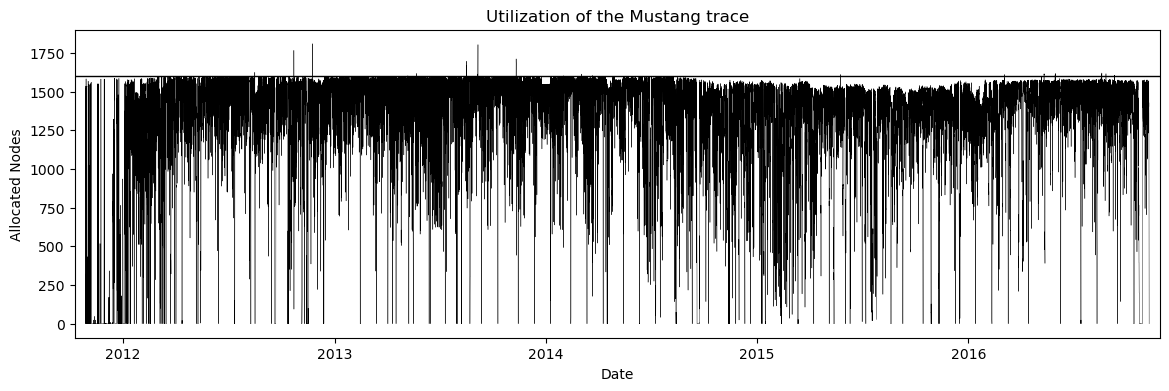

In [6]:
def node_series(arrive, depart, nodes, freq="1h"):
    """Nodes in use over time: +nodes at arrival, -nodes at departure,
    cumulative sum resampled to fixed bins."""
    events = pd.concat(
        [
            pd.Series(nodes.to_numpy(), index=arrive.to_numpy()),
            pd.Series(-nodes.to_numpy(), index=depart.to_numpy()),
        ]
    ).sort_index()
    return events.cumsum().resample(freq).last().ffill()


allocated = node_series(ran["start_time"], ran["end_time"], ran["node_count"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(allocated.index, allocated.to_numpy(), color="black", linewidth=0.3)
ax.axhline(NUM_NODES, color="black", linewidth=1)
ax.set_xlabel("Date")
ax.set_ylabel("Allocated Nodes")
ax.set_title("Utilization of the Mustang trace")
ax.margins(x=0.01)
plt.show()

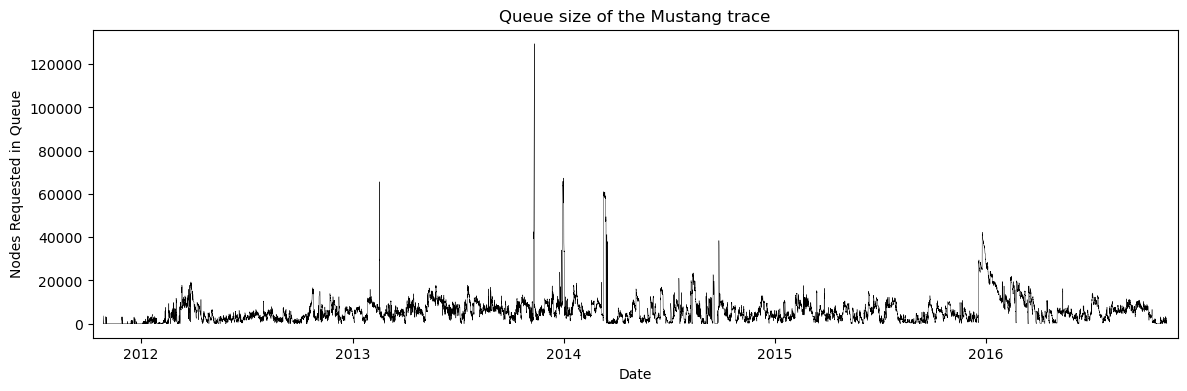

In [7]:
in_queue = node_series(queued["submit_time"], queued["depart_time"], queued["node_count"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(in_queue.index, in_queue.to_numpy(), color="black", linewidth=0.3)
ax.set_xlabel("Date")
ax.set_ylabel("Nodes Requested in Queue")
ax.set_title("Queue size of the Mustang trace")
ax.margins(x=0.01)
plt.show()

## Selecting 4-week extracts for replay

Goal: pick 4-week windows to replay in Batsim for evaluating environmental-aware scheduling (carbon and water intensity signals) against FCFS and EASY backfilling baselines.

The selection criteria differ from the classic high-load replay recommendations. Since the heuristics work by shifting jobs in time or toggling backfilling, the windows must exercise both regimes. And since intensity signals vary on diurnal and weather timescales, a window must span multiple weeks, not hours.

Two windows are selected:

- **slack**: busy but not saturated. The friendly regime for time-shifting, the gentle one for backfill toggling.
- **stress**: heavily saturated. The regime where the FCFS vs EASY gap is widest and disabling backfilling has real consequences.

Search range: the whole trace, candidate windows anchored at Monday 00:00 UTC and slid by 1 week. The anchoring keeps the weekly phase identical across extracts and traces. The feasibility constraints below take care of excluding the pathological periods (ramp-up, drains, single-user bursts). Metrics per candidate window, all normalized by machine size so they transfer to other traces:

- `mean_util`, `std_util`: average and variability of node utilization.
- `frac_saturated`: fraction of hours at >= 95% capacity.
- `frac_low`: fraction of hours below 20% utilization.
- `max_low_streak_h`: longest contiguous run of low-utilization hours. Catches drain or maintenance events that a scattered-hours budget would let through.
- `mean_queue_norm`: average nodes requested in queue, in units of machine capacity.
- `jobs_submitted`, `top_user_share`: job-mix sanity. A window dominated by one user's burst makes results fragile.
- `wide_ns_share`: node-seconds share of wide jobs (>= 10% of the machine). Wide jobs create the reservations that make EASY differ from FCFS.
- `frac_bf_candidates`: share of narrow short jobs (<= 1% of the machine, <= 2 h), the jobs EASY can slip into reservation holes.

In [8]:
WINDOW = pd.Timedelta(weeks=4)
WIDE_NODES = 0.10 * NUM_NODES
BF_NODES = 0.01 * NUM_NODES
BF_RUNTIME_SEC = 2 * 3600


def max_streak(mask):
    """Longest run of consecutive True values."""
    runs = mask.groupby((mask != mask.shift()).cumsum()).cumsum()
    return int(runs.max()) if len(runs) else 0


first_monday = (allocated.index[0].ceil("D") + pd.offsets.Week(weekday=0)).normalize()

rows = []
for start in pd.date_range(first_monday, allocated.index[-1] - WINDOW, freq="W-MON"):
    end = start + WINDOW
    util = allocated[start:end] / NUM_NODES
    replayed = ran[(ran["submit_time"] >= start) & (ran["submit_time"] < end)]
    node_sec = replayed["node_count"] * replayed["runtime_sec"]
    wide = replayed["node_count"] >= WIDE_NODES
    bf = (replayed["node_count"] <= BF_NODES) & (replayed["runtime_sec"] <= BF_RUNTIME_SEC)
    submitted = queued[(queued["submit_time"] >= start) & (queued["submit_time"] < end)]
    rows.append(
        {
            "start": start,
            "mean_util": util.mean(),
            "std_util": util.std(),
            "frac_saturated": (util >= 0.95).mean(),
            "frac_low": (util < 0.2).mean(),
            "max_low_streak_h": max_streak(util < 0.2),
            "mean_queue_norm": in_queue[start:end].mean() / NUM_NODES,
            "jobs_submitted": len(replayed),
            "top_user_share": submitted["user_ID"].value_counts(normalize=True).iloc[0]
            if len(submitted)
            else 1.0,
            "wide_ns_share": node_sec[wide].sum() / node_sec.sum() if node_sec.sum() else 0.0,
            "frac_bf_candidates": bf.mean() if len(replayed) else 0.0,
        }
    )
windows = pd.DataFrame(rows).set_index("start")
windows.round(3)

,mean_util,std_util,frac_saturated,frac_low,max_low_streak_h,mean_queue_norm,jobs_submitted,top_user_share,wide_ns_share,frac_bf_candidates
start,,,,,,,,,,
2011-10-31 00:00:00+00:00,0.147,0.339,0.137,0.837,253,0.053,948,0.529,0.892,0.314
2011-11-07 00:00:00+00:00,0.084,0.273,0.083,0.914,253,0.053,339,0.416,0.994,0.670
2011-11-14 00:00:00+00:00,0.076,0.259,0.074,0.921,190,0.056,384,0.360,0.993,0.635
2011-11-21 00:00:00+00:00,0.135,0.303,0.079,0.817,190,0.109,836,0.224,0.747,0.397
2011-11-28 00:00:00+00:00,0.157,0.305,0.059,0.773,190,0.248,1436,0.258,0.712,0.396
...,...,...,...,...,...,...,...,...,...,...
2016-09-12 00:00:00+00:00,0.896,0.116,0.392,0.006,3,4.662,7338,0.080,0.486,0.487
2016-09-19 00:00:00+00:00,0.841,0.225,0.357,0.052,32,3.879,7179,0.119,0.476,0.509
2016-09-26 00:00:00+00:00,0.762,0.305,0.285,0.114,45,2.580,9378,0.334,0.510,0.625


Feasibility constraints shared by both regimes:

- `frac_low <= 0.05` and `max_low_streak_h <= 6`: neither idle for long budgets nor hit by a contiguous drain.
- `top_user_share <= 0.5`: no single user dominates the job mix.
- `wide_ns_share >= 0.2` and `frac_bf_candidates >= 0.3`: enough wide jobs to force reservations and enough narrow short jobs to fill them, so EASY actually differs from FCFS.

Regime-specific constraints and ranking:

- **slack**: `0.5 <= mean_util <= 0.9` and `frac_saturated <= 0.3`. Ranked by `z(std_util) + z(mean_queue_norm)`: utilization variability indicates room to shift jobs, queue depth indicates sustained demand.
- **stress**: `mean_util <= 0.95` and `0.3 < frac_saturated <= 0.5`. Ranked by `z(frac_saturated) + z(mean_queue_norm)`: sustained pressure is the point of this regime.

In [9]:
def zscore(s):
    return (s - s.mean()) / s.std()


common = (
    (windows["frac_low"] <= 0.05)
    & (windows["max_low_streak_h"] <= 6)
    & (windows["top_user_share"] <= 0.5)
    & (windows["wide_ns_share"] >= 0.2)
    & (windows["frac_bf_candidates"] >= 0.3)
)

slack = windows[
    common & windows["mean_util"].between(0.5, 0.9) & (windows["frac_saturated"] <= 0.3)
].copy()
slack["score"] = zscore(slack["std_util"]) + zscore(slack["mean_queue_norm"])
slack = slack.sort_values("score", ascending=False)

stress = windows[
    common
    & (windows["mean_util"] <= 0.95)
    & (windows["frac_saturated"] > 0.3)
    & (windows["frac_saturated"] <= 0.5)
].copy()
stress["score"] = zscore(stress["frac_saturated"]) + zscore(stress["mean_queue_norm"])
stress = stress.sort_values("score", ascending=False)

EXTRACTS = {
    "slack": (slack.index[0], slack.index[0] + WINDOW),
    "stress": (stress.index[0], stress.index[0] + WINDOW),
}

for name, ranking in [("slack", slack), ("stress", stress)]:
    t0, t1 = EXTRACTS[name]
    print(f"{name}: {len(ranking)} feasible windows, selected {t0.date()} -> {t1.date()}")
pd.concat([slack.head(3), stress.head(3)], keys=["slack", "stress"]).round(3)

slack: 3 feasible windows, selected 2015-04-13 -> 2015-05-11
stress: 18 feasible windows, selected 2013-01-07 -> 2013-02-04


mean_util  std_util  frac_saturated  \
       start                                                            
slack  2015-04-13 00:00:00+00:00      0.856     0.119           0.098   
       2014-10-13 00:00:00+00:00      0.843     0.147           0.097   
       2015-09-14 00:00:00+00:00      0.860     0.099           0.010   
stress 2013-01-07 00:00:00+00:00      0.919     0.098           0.487   
       2014-07-14 00:00:00+00:00      0.891     0.142           0.481   
       2012-12-31 00:00:00+00:00      0.912     0.102           0.481   

                                  frac_low  max_low_streak_h  mean_queue_norm  \
       start                                                                    
slack  2015-04-13 00:00:00+00:00     0.006                 3            3.306   
       2014-10-13 00:00:00+00:00     0.000                 0            2.872   
       2015-09-14 00:00:00+00:00     0.000                 0            3.274   
stress 2013-01-07 00:00:00+00:00     0.000                 0            3.942   
       2014-07-14 00:00:00+00:00     0.004                 2            3.850   
       2012-12-31 00:00:00+00:00     0.000                 0            2.943   

                                  jobs_submitted  top_user_share  \
       start                                                       
slack  2015-04-13 00:00:00+00:00           10683           0.152   
       2014-10-13 00:00:00+00:00           18295           0.401   
       2015-09-14 00:00:00+00:00            7693           0.222   
stress 2013-01-07 00:00:00+00:00            5089           0.215   
       2014-07-14 00:00:00+00:00           16723           0.308   
       2012-12-31 00:00:00+00:00            4303           0.262   

                                  wide_ns_share  frac_bf_candidates  score  
       start                                                                
slack  2015-04-13 00:00:00+00:00          0.501               0.450  0.530  
       2014-10-13 00:00:00+00:00          0.386               0.736 -0.100  
       2015-09-14 00:00:00+00:00          0.417               0.466 -0.430  
stress 2013-01-07 00:00:00+00:00          0.582               0.629  1.826  
       2014-07-14 00:00:00+00:00          0.505               0.737  1.613  
       2012-12-31 00:00:00+00:00          0.596               0.591  0.814

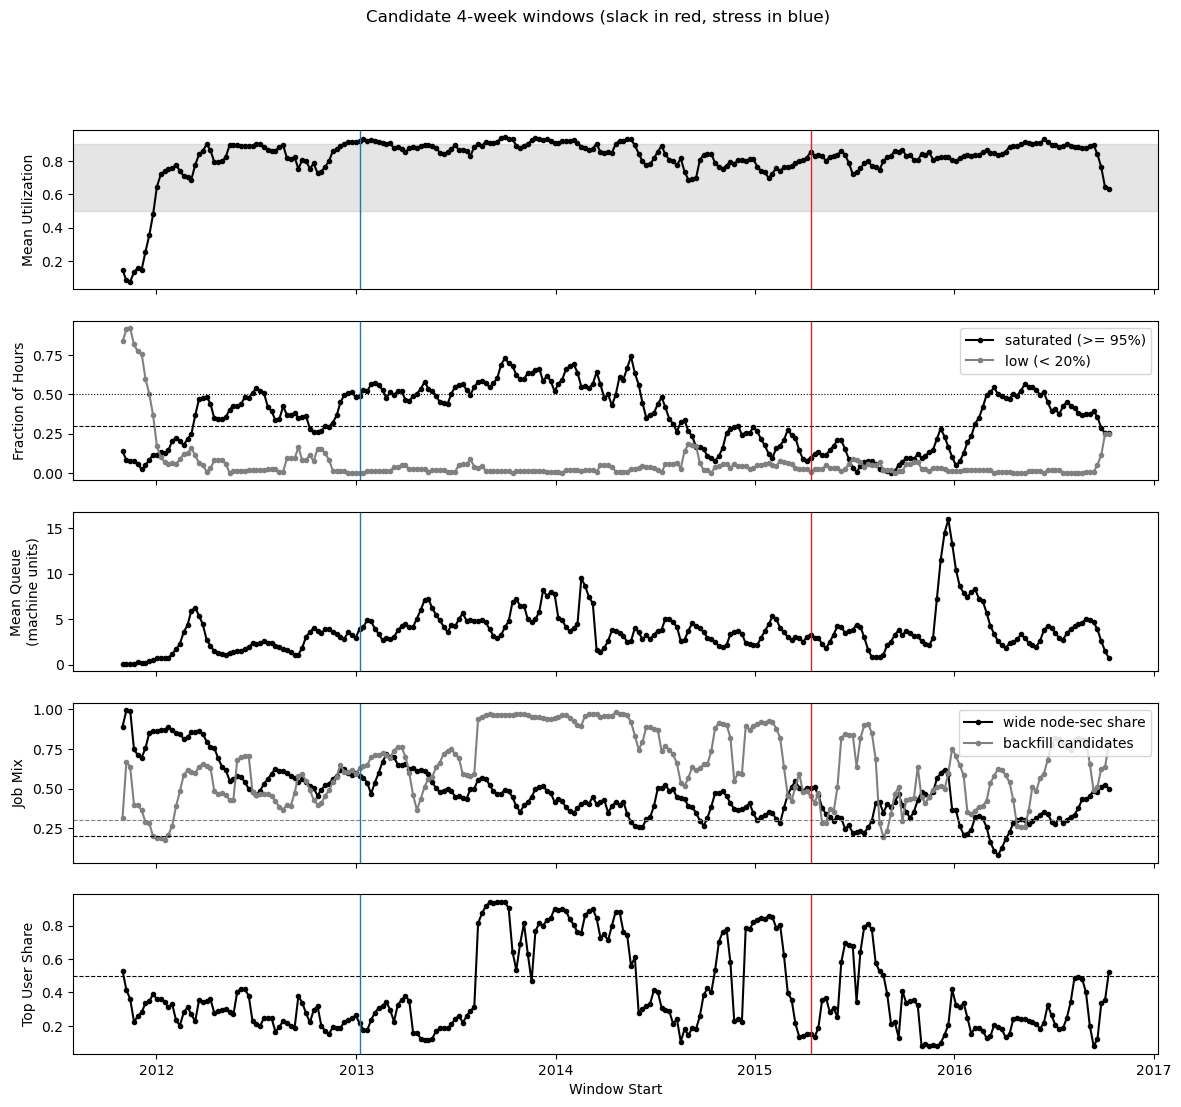

In [10]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

axes[0].plot(windows.index, windows["mean_util"], marker=".", color="black")
axes[0].axhspan(0.5, 0.9, color="gray", alpha=0.2)
axes[0].set_ylabel("Mean Utilization")

axes[1].plot(windows.index, windows["frac_saturated"], marker=".", color="black", label="saturated (>= 95%)")
axes[1].plot(windows.index, windows["frac_low"], marker=".", color="gray", label="low (< 20%)")
axes[1].axhline(0.3, color="black", linewidth=0.8, linestyle="--")
axes[1].axhline(0.5, color="black", linewidth=0.8, linestyle=":")
axes[1].set_ylabel("Fraction of Hours")
axes[1].legend()

axes[2].plot(windows.index, windows["mean_queue_norm"], marker=".", color="black")
axes[2].set_ylabel("Mean Queue\n(machine units)")

axes[3].plot(windows.index, windows["wide_ns_share"], marker=".", color="black", label="wide node-sec share")
axes[3].plot(windows.index, windows["frac_bf_candidates"], marker=".", color="gray", label="backfill candidates")
axes[3].axhline(0.2, color="black", linewidth=0.8, linestyle="--")
axes[3].axhline(0.3, color="gray", linewidth=0.8, linestyle="--")
axes[3].set_ylabel("Job Mix")
axes[3].legend()

axes[4].plot(windows.index, windows["top_user_share"], marker=".", color="black")
axes[4].axhline(0.5, color="black", linewidth=0.8, linestyle="--")
axes[4].set_ylabel("Top User Share")
axes[4].set_xlabel("Window Start")

for ax in axes:
    ax.axvline(EXTRACTS["slack"][0], color="tab:red", linewidth=1)
    ax.axvline(EXTRACTS["stress"][0], color="tab:blue", linewidth=1)
fig.suptitle("Candidate 4-week windows (slack in red, stress in blue)")
plt.show()

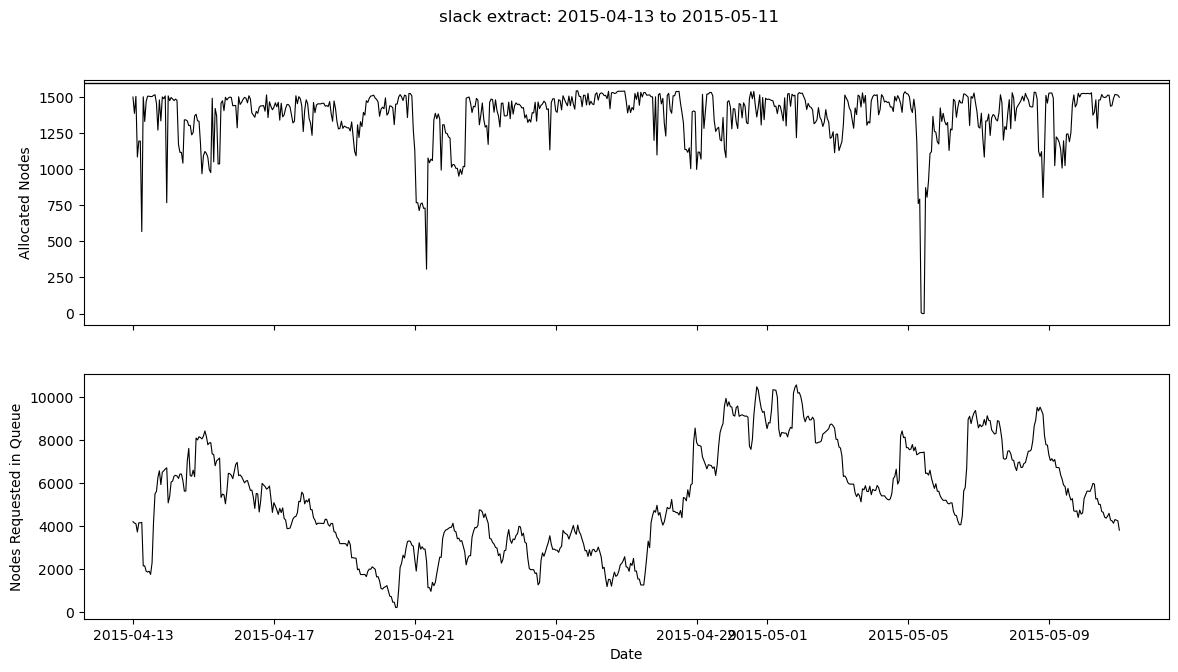

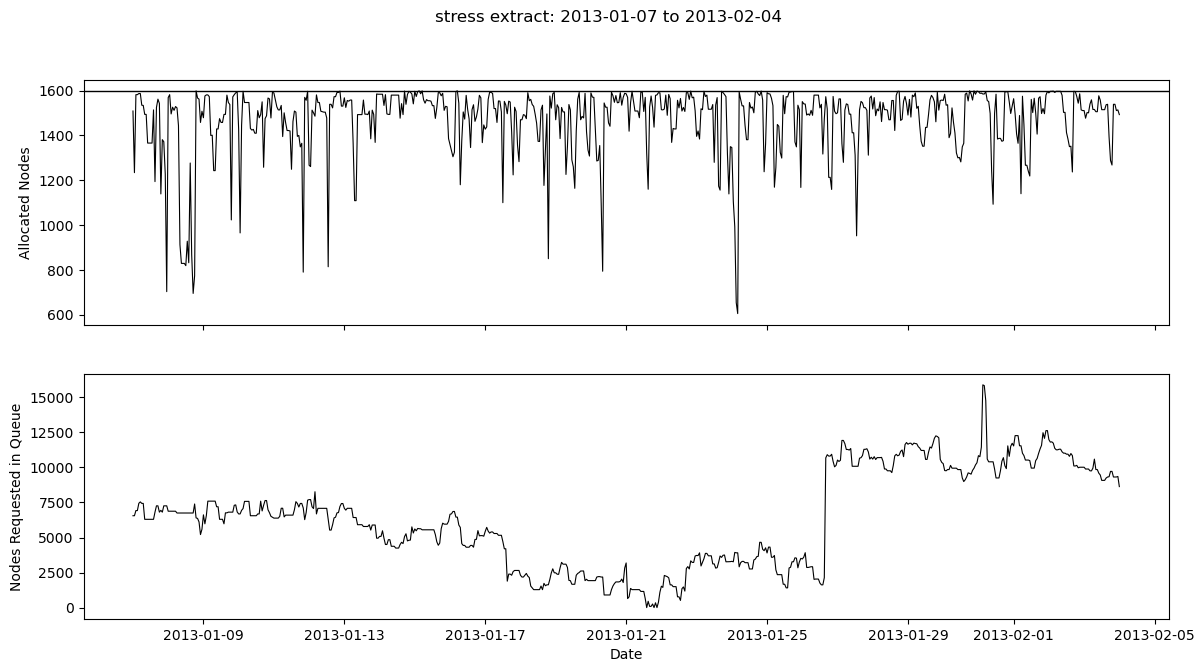

In [11]:
for name, (t0, t1) in EXTRACTS.items():
    fig, (ax_util, ax_queue) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    window_alloc = allocated[t0:t1]
    ax_util.plot(window_alloc.index, window_alloc.to_numpy(), color="black", linewidth=0.8)
    ax_util.axhline(NUM_NODES, color="black", linewidth=1)
    ax_util.set_ylabel("Allocated Nodes")

    window_queue = in_queue[t0:t1]
    ax_queue.plot(window_queue.index, window_queue.to_numpy(), color="black", linewidth=0.8)
    ax_queue.set_ylabel("Nodes Requested in Queue")
    ax_queue.set_xlabel("Date")

    fig.suptitle(f"{name} extract: {t0.date()} to {t1.date()}")
    plt.show()

## Batsim workload generation

One workload JSON per extract. Each job gets its own `parallel_homogeneous` profile with `cpu = runtime_sec * node_speed` and `com = 0` (network not modelled).

Jobs carry a walltime estimate because the EASY implementation (`easy_bf`) rejects jobs without one and builds its reservations from it. The estimate is the trace's `wallclock_limit` clipped so that `runtime <= walltime` always holds (walltime violations are not modelled, so TIMEOUT jobs that overran their limit in the real system get their walltime raised to the runtime).

> **Behavioral note**: because TIMEOUT jobs get `walltime = runtime` exactly, EASY's estimate for them is perfect, while every other job keeps its real, often loose, user estimate. This is the standard compromise when walltime violations are not modelled, but it slightly flatters backfilling accuracy for those jobs (about 7% of the trace).

Warm-up: the simulation starts with an empty machine, which the real system never was. To reproduce the system state at the extract start `T0`, all jobs that were in the system at `T0` are reset in the same state:

- **running at T0** (`start < T0 <= end`): submitted at `t = 0` with their *remaining* runtime and remaining walltime, ordered by original start time so FCFS reproduces the allocation order.
- **queued at T0** (`submit < T0 <= start`): submitted at `t = 0` with their full runtime, ordered by original submit time so they keep their queue positions. Jobs cancelled while queued are excluded since they have no defined runtime.

This defines two periods: the **warm-up** (environment setup at `t = 0`) and the **steady state**, which starts when the first replay job is submitted. Replay jobs are those submitted inside `[T0, T0 + 4 weeks)`, with `subtime` relative to `T0`. Evaluation metrics should be computed on the steady state only.

In [12]:
def job_entry(job_id, subtime, res, runtime_sec, walltime_sec, jobs, profiles):
    profiles[job_id] = {
        "type": "parallel_homogeneous",
        "cpu": float(runtime_sec) * node_speed,
        "com": 0.0,
    }
    jobs.append(
        {
            "id": job_id,
            "subtime": float(subtime),
            "res": int(res),
            "walltime": int(max(walltime_sec, np.ceil(runtime_sec))),
            "profile": job_id,
        }
    )


def build_workload(t0, t1):
    """Batsim workload for the extract [t0, t1): warm-up context jobs at t=0,
    then the replayed jobs with their original arrival offsets."""
    running = ran[(ran["start_time"] < t0) & (ran["end_time"] >= t0)]
    waiting = ran[(ran["submit_time"] < t0) & (ran["start_time"] >= t0)]
    replay = ran[(ran["submit_time"] >= t0) & (ran["submit_time"] < t1)]

    jobs, profiles = [], {}
    for i, row in enumerate(running.sort_values("start_time").itertuples(), start=1):
        elapsed = (t0 - row.start_time).total_seconds()
        remaining = max((row.end_time - t0).total_seconds(), 1.0)
        job_entry(
            f"ctx_run{i}", 0.0, row.node_count, remaining,
            row.walltime_sec - elapsed, jobs, profiles,
        )
    for i, row in enumerate(waiting.sort_values("submit_time").itertuples(), start=1):
        job_entry(
            f"ctx_queued{i}", 0.0, row.node_count, row.runtime_sec,
            row.walltime_sec, jobs, profiles,
        )
    for i, row in enumerate(replay.sort_values("submit_time").itertuples(), start=1):
        subtime = (row.submit_time - t0).total_seconds()
        job_entry(
            f"job{i}", subtime, row.node_count, row.runtime_sec,
            row.walltime_sec, jobs, profiles,
        )

    return {"nb_res": NUM_NODES, "jobs": jobs, "profiles": profiles}


for name, (t0, t1) in EXTRACTS.items():
    workload = build_workload(t0, t1)
    out_path = f"mustang_{name}.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(workload, f, indent=2)

    by_kind = {"ctx_run": 0, "ctx_queued": 0, "job": 0}
    for job in workload["jobs"]:
        by_kind[job["id"].rstrip("0123456789")] += 1
    nodes_running_t0 = sum(
        j["res"] for j in workload["jobs"] if j["id"].startswith("ctx_run")
    )
    steady_start = min(
        j["subtime"] for j in workload["jobs"] if j["id"].startswith("job")
    )
    print(
        f"{out_path}: {by_kind['ctx_run']} running + {by_kind['ctx_queued']} queued ctx jobs "
        f"({nodes_running_t0} nodes busy at t=0), {by_kind['job']} replay jobs, "
        f"steady state from t={steady_start:.0f}s"
    )

mustang_slack.json: 22 running + 40 queued ctx jobs (1478 nodes busy at t=0), 10683 replay jobs, steady state from t=48s
mustang_stress.json: 14 running + 17 queued ctx jobs (1106 nodes busy at t=0), 5089 replay jobs, steady state from t=1265s


## SimGrid platform generation

Homogeneous platform modelled after Mustang. Nodes are modelled at full-node granularity: no `core` attribute, each host computes at `node_speed` flops. Power states follow the SimGrid `wattage_per_state` format `idle:epsilon:all_cores`.

In [13]:
def create_prop(parent, prop_id, value):
    prop = ET.SubElement(parent, "prop")
    prop.set("id", prop_id)
    prop.set("value", value)


def generate_platform_xml(output_file, num_nodes=NUM_NODES):
    platform = ET.Element("platform")
    platform.set("version", "4.1")

    zone = ET.SubElement(platform, "zone")
    zone.set("id", ZONE_ID)
    zone.set("routing", "Full")

    # Management/login node, not a compute node. Batsim identifies the master
    # host by name and assigns its role automatically, so no role property is
    # needed. SimGrid requires a speed attribute on every host, and the energy
    # plugin requires wattage_per_state, so both are set to nominal values.
    master = ET.SubElement(zone, "host")
    master.set("id", "master_host")
    master.set("speed", "1Gf")
    create_prop(master, "wattage_per_state", "0:0:0")

    wattage = f"{IDLE_POWER_WATT}:{EPSILON_POWER_WATT}:{ALLCORES_POWER_WATT}"
    for i in range(num_nodes):
        node = ET.SubElement(zone, "host")
        node.set("id", f"node-{i}")
        node.set("speed", f"{node_speed / 1e9:g}Gf")
        create_prop(node, "role", "compute_node")
        create_prop(node, "wattage_per_state", wattage)

    tree = ET.ElementTree(platform)
    ET.indent(tree, space="    ")
    with open(output_file, "w") as f:
        f.write("<?xml version='1.0'?>\n")
        f.write('<!DOCTYPE platform SYSTEM "http://simgrid.gforge.inria.fr/simgrid/simgrid.dtd">\n')
        tree.write(f, encoding="unicode", xml_declaration=False)
    print(f"generated platform with {num_nodes} nodes at: {output_file}")


generate_platform_xml("mustang.xml")

generated platform with 1600 nodes at: mustang.xml


# References

[1] G. Amvrosiadis, J. W. Park, G. R. Ganger, G. A. Gibson, E. Baseman, and N. DeBardeleben, “On the diversity of cluster workloads and its impact on research results,” in 2018 USENIX annual technical conference (USENIX ATC 18), Boston, MA: USENIX Association, Jul. 2018, pp. 533–546. [Online]. Available: https://www.usenix.org/conference/atc18/presentation/amvrosiadis

[2] J. Emeras, “Workload Traces Analysis and Replay in Large Scale Distributed Systems,” Université Grenoble Alpes, 2013.

[3] E. Frachtenberg and D. G. Feitelson, “Pitfalls in parallel job scheduling evaluation,” in Job scheduling strategies for parallel processing, vol. 3834, D. Feitelson, E. Frachtenberg, L. Rudolph, and U. Schwiegelshohn, Eds., in Lecture Notes in Computer Science, vol. 3834. , Berlin, Heidelberg: Springer Berlin Heidelberg, 2005, pp. 257–282. doi: 10.1007/11605300_13.